# 🚀 Backtest Vectorisé : Stratégie Regime-Switching Momentum
Ce notebook contient **absolument tout le code source** (fonctions, classe, imports) pour que tu puisses le modifier et l'exécuter d'une traite sans dépendre de fichiers externes.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import yfinance as yf
import ta
import warnings
from datetime import datetime
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# ==========================================
# 1. SETUP DE L'ENVIRONNEMENT & SPARK
# ==========================================
# Fix random seeds for reproducibility
np.random.seed(42)

# Remonter à la racine du projet de manière robuste (Ton code)
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())
load_dotenv()

try:
    from src.common.setup_spark import create_spark_session
    from config.config_spark import Paths
    print("✅ Imports locaux réussis !")
except Exception as e:
    print(f"❌ Erreur d'importation locale : {e}")
    sys.exit(1)

print("🚀 Initialisation de la Spark Session...")
spark = create_spark_session("Regime_Switching_Backtest")
print("✅ Spark Session créée avec succès.")


2026-03-28 17:32:33.051 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


✅ Imports locaux réussis !
🚀 Initialisation de la Spark Session...


26/03/28 17:32:33 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/28 17:32:33 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-151648b9-120b-4710-9ac5-92f5ad8c240b;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 67ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|   

:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


26/03/28 17:32:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
2026-03-28 17:32:36.323 | SUCCESS  | src.common.setup_spark:create_spark_session:38 - ✅ Spark Session 'Regime_Switching_Backtest' créée avec succès ! (Version: 3.5.3)


✅ Spark Session créée avec succès.


In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import ta
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

class RegimeSwitchingMomentumBacktester:
    def __init__(self, start_date="2010-01-01", end_date=None):
        self.start_date = start_date
        self.end_date = end_date or datetime.today().strftime('%Y-%m-%d')
        
        self.etf_tickers = [
            'XLP', 'XLV', 'XLU', 'XLE', 'XLK', 'XLC', 'XLI', 'XLY', 
            'XLB', 'XLRE', 'TLT', 'IEF', 'HYG', 'GLD', 'VNQ'
        ]
        
    def get_sp500_regime(self) -> pd.DataFrame:
        print("📈 Fetching S&P 500 data for Regime Filter...")
        sp500 = yf.download('^GSPC', start=self.start_date, end=self.end_date, progress=False)
        sp500 = pd.DataFrame(sp500['Close'].resample('W-FRI').last())
        sp500.columns = ['Close']
        sp500['SMA_12'] = ta.trend.sma_indicator(sp500['Close'], window=26)
        sp500['SMA_26'] = ta.trend.sma_indicator(sp500['Close'], window=70)
        
        cond_bull = (sp500['SMA_12'] > sp500['SMA_26']) & (sp500['Close'] > sp500['SMA_26']) | (sp500['SMA_12'] < sp500['SMA_26']) & (sp500['Close'] > sp500['SMA_12'])
        sp500['Regime'] = np.where(cond_bull, 'Bull', 'Bear')
        
        sp500.index = pd.to_datetime(sp500.index).tz_localize(None).normalize()
        return sp500[['Close', 'SMA_12', 'SMA_26', 'Regime']]
        
    def get_etf_data(self) -> pd.DataFrame:
        print("🛡️ Fetching ETF data...")
        etf_data = yf.download(self.etf_tickers, start=self.start_date, end=self.end_date, progress=False)
        etf_close = etf_data['Close'].resample('W-FRI').last()
        
        df_list = []
        for ticker in self.etf_tickers:
            df = etf_close[[ticker]].dropna().rename(columns={ticker: 'Close'})
            df['Ticker'] = ticker
            
            df['SMA_12'] = ta.trend.sma_indicator(df['Close'], window=12)
            df['SMA_26'] = ta.trend.sma_indicator(df['Close'], window=26)
            df['SMA_55'] = ta.trend.sma_indicator(df['Close'], window=55)
            df['Momentum_3M'] = df['Close'].pct_change(periods=13)
            
            df['Eligible'] = (df['SMA_12'] > df['SMA_26']) & (df['Close'] > df['SMA_26'])
            df_list.append(df.reset_index())
            
        res = pd.concat(df_list, ignore_index=True)
        res = res.rename(columns={'Date': 'date'})
        res['date'] = pd.to_datetime(res['date']).dt.tz_localize(None).dt.normalize()
        return res

    def load_and_prep_stock_data(self, spark_session) -> pd.DataFrame:
        print(f"📡 Loading Daily S&P 500 Constituent Data from: {Paths.SP500_STOCK_PRICES}")
        df_bronze = spark_session.read.format("delta").load(Paths.SP500_STOCK_PRICES)
        pd_df = df_bronze.select('date', 'symbol', 'adjHigh', 'adjLow', 'adjClose').toPandas()
        
        pd_df['date'] = pd.to_datetime(pd_df['date']).dt.tz_localize(None).dt.normalize()
        print(f"Loaded {len(pd_df)} daily price records. Processing indicators and resampling to weekly...")

        results = []
        for symbol, df in pd_df.groupby('symbol'):
            df = df.sort_values('date').set_index('date')
            if len(df) < 130:
                continue
            
            df['ADX_20'] = ta.trend.adx(df['adjHigh'], df['adjLow'], df['adjClose'], window=20, fillna=True)
            df['ATR_14'] = ta.volatility.average_true_range(df['adjHigh'], df['adjLow'], df['adjClose'], window=14, fillna=True)
            
            weekly_df = df.resample('W-FRI').agg({
                'adjClose': 'last', 'ADX_20': 'last', 'ATR_14': 'last'
            }).dropna(subset=['adjClose'])
            
            weekly_df['SMA_12'] = ta.trend.sma_indicator(weekly_df['adjClose'], window=12)
            weekly_df['SMA_26'] = ta.trend.sma_indicator(weekly_df['adjClose'], window=26)
            
            # 👇 LIGNE À MODIFIER POUR TES TESTS DE MOYENNE MOBILE
            weekly_df['SMA_STOP'] = ta.trend.sma_indicator(weekly_df['adjClose'], window=55) 
            
            weekly_df['ATR_pct'] = weekly_df['ATR_14'] / weekly_df['adjClose']
            weekly_df['Momentum_3M'] = weekly_df['adjClose'].pct_change(periods=12)
            weekly_df['Momentum_1W'] = weekly_df['adjClose'].pct_change(periods=1)
            
            # Attention : Ton filtre d'achat initial exigeait que le prix soit au-dessus de SMA_26
            cond_trend = (weekly_df['adjClose'] > weekly_df['SMA_26']) & (weekly_df['SMA_26'] > weekly_df['SMA_STOP'])
            cond_strength = weekly_df['ADX_20'] > 20
            cond_volatility = weekly_df['ATR_pct'] < 0.1
            cond_1W = weekly_df['Momentum_1W'] < 0.0           
            
            weekly_df['Eligible'] = cond_trend & cond_strength & cond_volatility & cond_1W
            weekly_df['Ticker'] = symbol
            results.append(weekly_df.reset_index())

        if not results:
            return pd.DataFrame()

        final_df = pd.concat(results, ignore_index=True)
        return final_df.dropna()

    def simulate_portfolio(self, sp500, etfs, stocks):
        print("⚙️ Lancement de la Simulation Vectorisée (PURE MOMENTUM - No Macro Filter)...")
        
        # 🎛️ PARAMÈTRE DE LEVIER (Mets 1.5 pour comparer avec ta Golden Version)
        LEVERAGE = 1.5 
        
        if not stocks.empty:
            stocks['date'] = pd.to_datetime(stocks['date']).dt.normalize()
            
        # On ne croise plus avec les ETFs ni le SP500, on utilise uniquement le calendrier des actions
        dates = sorted(stocks['date'].unique())
        if not dates: return pd.DataFrame()
        
        df_dates = pd.DataFrame({'date': dates})
        rebalance_dates_series = df_dates.groupby(df_dates['date'].dt.to_period('M'))['date'].max()
        rebalance_dates_str = set(date.strftime('%Y-%m-%d') for date in rebalance_dates_series)
        
        portfolio_allocations = {}
        current_portfolio = [] 
        trades_count = 0
        
        for d in dates:
            d_str = d.strftime('%Y-%m-%d')
            
            # --- 1. FILTRE HEBDOMADAIRE (Stop-Loss Défensif) ---
            surviving_portfolio = []
            for pos in current_portfolio:
                ticker = pos['Ticker']
                kept = True 
                
                asset_mask = (stocks['date'] == d) & (stocks['Ticker'] == ticker)
                if asset_mask.any():
                    price = stocks[asset_mask].iloc[0]['adjClose']
                    ma_stop = stocks[asset_mask].iloc[0]['SMA_STOP'] 
                    
                    # Le couperet de la SMA 50
                    if price < ma_stop: kept = False 
                        
                if kept: surviving_portfolio.append(pos)
                    
            current_portfolio = surviving_portfolio

            # --- 2. REBALANCEMENT MENSUEL ---
            if d_str in rebalance_dates_str:
                daily_stocks = stocks[stocks['date'] == d].copy()
                
                if not daily_stocks.empty:
                    current_tickers = [p['Ticker'] for p in current_portfolio]
                    
                    # 🥇 Classement global
                    daily_stocks['Rank'] = daily_stocks['Momentum_3M'].rank(ascending=False, method='first')
                    
                    # -- ÉTAPE A : Le Buffer Top 15 --
                    kept_tickers = []
                    for ticker in current_tickers:
                        ticker_data = daily_stocks[daily_stocks['Ticker'] == ticker]
                        if not ticker_data.empty and ticker_data.iloc[0]['Rank'] <= 15:
                            kept_tickers.append(ticker)
                                    
                    # -- ÉTAPE B : Remplir les trous --
                    new_portfolio = [{'Ticker': t, 'Weight': 0.1, 'Type': 'Stock'} for t in kept_tickers]
                    places_libres = 10 - len(kept_tickers)
                    
                    if places_libres > 0:
                        eligible_stocks = daily_stocks[daily_stocks['Eligible']]
                        candidates = eligible_stocks[~eligible_stocks['Ticker'].isin(kept_tickers)]
                        
                        top_new = candidates.nsmallest(places_libres, 'Rank') 
                        for _, row in top_new.iterrows():
                            new_portfolio.append({'Ticker': row['Ticker'], 'Weight': 0.1, 'Type': 'Stock'})
                            trades_count += 1
                                
                    current_portfolio = new_portfolio
                    
                    # -- ÉTAPE C : Pondération dynamique --
                    n_assets = len(current_portfolio)
                    if n_assets > 0:
                        dyn_weight = LEVERAGE / n_assets
                        for pos in current_portfolio: pos['Weight'] = dyn_weight
            
            # --- 3. ENREGISTREMENT ---
            current_target = {pos['Ticker']: pos['Weight'] for pos in current_portfolio}
            portfolio_allocations[d] = current_target
            
        print(f"✅ Backtest terminé. Total de NOUVEAUX ACHATS exécutés : {trades_count}")
        return pd.DataFrame(portfolio_allocations).T.fillna(0)

In [ ]:
# --- EXECUTION DU BACKTEST ---
backtester = RegimeSwitchingMomentumBacktester(start_date="1900-01-01")

print("1. Calcul du Regime de Marché...")
sp500 = backtester.get_sp500_regime()

print("2. Calcul des indicateurs ETFs...")
etfs = backtester.get_etf_data()

print("3. Chargement et traitement des 3.8M de lignes Actions (Daily -> Weekly)...")
stocks = backtester.load_and_prep_stock_data(spark)

print("4. Simulation du portefeuille (Vectorisation)...")
allocations = backtester.simulate_portfolio(sp500, etfs, stocks)

print("Aperçu des pondérations cibles du portefeuille (Dernières semaines) :")
display(allocations.tail())


1. Calcul du Regime de Marché...
📈 Fetching S&P 500 data for Regime Filter...
2. Calcul des indicateurs ETFs...
🛡️ Fetching ETF data...
3. Chargement et traitement des 3.8M de lignes Actions (Daily -> Weekly)...
📡 Loading Daily S&P 500 Constituent Data from: gs://finance-data-lake-unique-id/bronze/sp500_stock_prices


Loaded 3706956 daily price records. Processing indicators and resampling to weekly...
4. Simulation du portefeuille (Vectorisation)...
⚙️ Lancement de la Simulation Vectorisée (PURE MOMENTUM - No Macro Filter)...
✅ Backtest terminé. Total de NOUVEAUX ACHATS exécutés : 3994
Aperçu des pondérations cibles du portefeuille (Dernières semaines) :


,MRO,ED,DTE,XOM,CVX,MO,PG,KO,CAT,MSI,IP,GT,MMM,MRK,IBM,AEP,GD,BA,KR,RTX,GE,SLB,PFE,CLX,SR,HON,XEL,EIX,SO,CMS,PEG,PEP,CMI,CVS,HAL,EMR,NSC,UNP,F,CPB,PPG,ETN,DE,CL,MCD,GIS,SHW,LLY,ABT,COP,ETR,KMB,PCH,NOC,WOR,OXY,PBI,LMT,BAX,SKY,BC,EXC,GCO,OMC,SPGI,HPQ,BMY,HSY,JPM,CCK,DUK,BDX,CNA,BAC,JNJ,TGNA,LPX,INTC,TRV,WFC,NEE,NEM,AXP,BMS,LNC,WMB,MSA,HUM,TGT,TAP,RAD,AIG,ADM,CSX,WBA,IFF,WY,MAS,THC,ADP,PCAR,LHX,C,WEN,GWW,BSET,FDX,TXT,SNA,MAT,DIS,GPC,CI,BF-B,D,BBWI,R,SCI,AIT,MEI,WMT,AAPL,LOW,CB,PHM,BALL,HAS,CNP,T,PH,APD,ITW,DOV,HES,JCI,NYT,FNB,VZ,GPS,CR,CAG,DDS,BKR,SYY,MKC,SPXC,HRB,AVY,MMC,MRSH,RVTY,HD,MDT,NUE,NKE,ADSK,K,DLX,AMD,TJX,PCLB,ORCL,KBH,GL,PNC,ASH,SVU,AMGN,ECL,MS,MSFT,CSCO,COST,LUV,EMN,SWK,KEY,UNH,LIN,MAR,CAR,NWL,GLW,UNM,BK,USB,FITB,IPG,AMAT,BSX,JWN,MTG,FCN,LSI,EHC,HIG,PPL,YUM,EFX,MU,CSR,AEE,FE,KLAC,SCHW,ADBE,STT,SEE,APA,PAR,TUP,CINF,PAYX,AES,KSS,NTAP,BEN,L,CAH,MCK,SLM,WM,TFC,RF,CCL,MCO,SRE,VMC,AZO,HBAN,BBY,DRI,DHR,BIG,CVG,FCX,IGT,SYK,ROK,ZBH,NBR,LUMN,NVDA,SANM,COF,EBAY,GEN,TXN,CTAS,A,VIAV,NCR,LEG,SBUX,BBBY,VLO,RIG,HOG,WAT,QCOM,EOG,EQR,PGR,PFG,AT,EA,TROW,HOT,PRU,QLGC,ODP,COL,FI,FISV,SPG,DGX,COR,ESRX,AFL,BRCM,ATI,AON,VTRS,GILD,BNI,CTXS,JNS,FLR,AGN,INTU,LH,PMCS,AIV,SNV,PSA,SOV,AMP,TPR,CMCSA,TSG,TSN,EL,TIF,NOV,HCR,AMZN,TT,JNPR,APOL,BIIB,ELV,VAR,SSP,VRSN,AIZ,FIS,STJ,WU,CPWR,KIM,SWN,TDC,CBRE,MA,GNW,RRD,PSKY,LEN,EXPE,CIEN,AKAM,CTSH,PNW,ISRG,MTB,LXK,ZION,HST,WYNN,CHRW,GHC,AAL,SJM,AMT,SRCL,APH,PM,MUR,FTI,EXPD,TER,JEF,CLF,CAM,WELL,PDCO,ANDV,GME,WDC,CERN,ANF,ATGE,GOOG,GOOGL,ORLY,RRC,OKE,FAST,CELG,ROST,RL,DHI,DFS,WEC,ES,CF,FLS,DTV,URBN,STZ,KMX,NFLX,MPC,CTRA,NDAQ,EQT,LDOS,CME,WPX,IVZ,FLIR,ETFC,TSS,BWA,SB,CRM,STX,FSLR,XYL,CMG,PSX,ALXN,MNST,FFIV,XLNX,NFX,GRMN,DVN,CNX,IRM,LRCX,KMI,RSG,EW,REGN,LYB,MJN,ADI,MAC,VTR,MHK,DLTR,WFM,NI,GS,META,MDLZ,DAL,HRL,BKNG,J,WB,LLTC,UAL,SYF,CSRA,QRVO,SWKS,URI,RCL,PNR,PYPL,ZTS,VRTX,NRG,ALL,FMC,ABBV,ALB,CNC,NWSA,NWS,AJG,CPRI,TSCO,BLK,HCA,DVA,HPE,TRIP,FOX,AAP,DG,WBD,DOC,O,ULTA,TDG,AVGO,AWK,IR,EG,CHD,EQIX,GPN,IDXX,ICE,DISH,CCI,CBOE,LKQ,UHS,KSU,PWR,ANSS,FTNT,COO,VRSK,SBAC,MSCI,ATVI,ALGN,KHC,TTWO,ABMD,TMO,FBIN,CTVA,SIVB,RMD,MGM,MOS,PVH,FRC,FANG,HBI,IT,HSIC,DPZ,ANET,MTD,TWTR,TYL,WST,DXCM,CDNS,ETSY,PLD,LW,DRE,NLSN,ROL,RJF,WTW,CDW,NVR,CPRT,NOW,STE,CEG,CHTR,MOH,SNPS,S,CE,MPWR,ALLE,STLD,MRNA,TRGP,FICO,AXON,BXP,NCLH,TSLA,LYV,BX,PAYC,GEHC,BRO,UBER,DLR,TDY,LVS,CRL,GNRC,BG
2026-02-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [8]:
# 1. On "empile" le tableau pour avoir une série (Date / Ticker / Poids)
positions_actives = allocations.stack()

# 2. On filtre pour ne garder QUE les poids strictement supérieurs à zéro
positions_actives = positions_actives[positions_actives > 0].reset_index()

# 3. On renomme les colonnes pour faire propre
positions_actives.columns = ['Date', 'Ticker', 'Poids_Cible']

# Affichage du journal des trades
print(f"🔎 Le robot a détenu {len(positions_actives)} positions actives sur toute la période.")
display(positions_actives.tail(20)) # Affiche les 20 derniers investissements

🔎 Le robot a détenu 24918 positions actives sur toute la période.


,Date,Ticker,Poids_Cible
24898,2026-03-13,LMT,0.15
24899,2026-03-13,NEM,0.15
24900,2026-03-13,FDX,0.15
24901,2026-03-13,AMAT,0.15
24902,2026-03-13,MU,0.15
24903,2026-03-13,FCX,0.15
24904,2026-03-13,TER,0.15
24905,2026-03-13,WDC,0.15
24906,2026-03-13,STX,0.15
24907,2026-03-13,LRCX,0.15


📊 Calcul des rendements nets (Pure Momentum)...


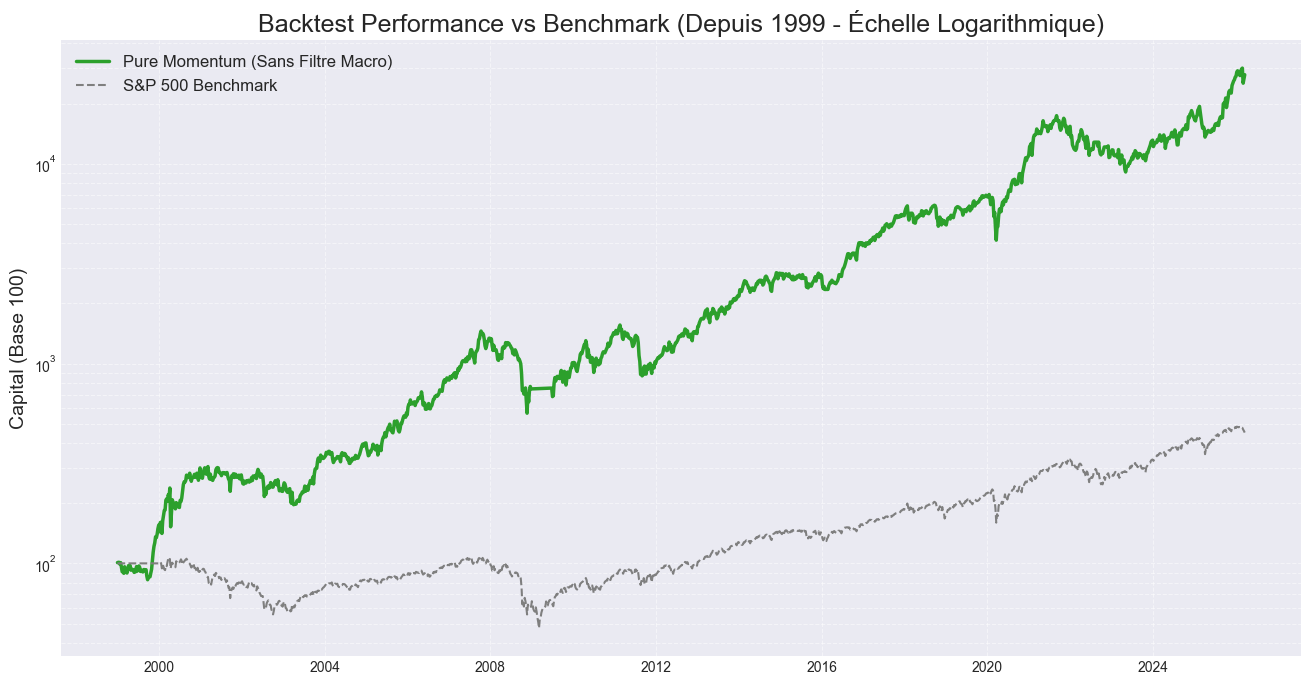

💰 Turnover moyen hebdomadaire : 49.99%
📈 Exposition brute moyenne (Gross Exposure) : 144.36%
📊 CAGR Net: 22.99% | Sharpe Net: 0.74 | Max DD: -61.19%


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

TRANSACTION_FEE = 0.001       
CASH_YIELD_ANNUAL = 0.02      
MARGIN_RATE_ANNUAL = 0.06     

CASH_YIELD_WEEKLY = CASH_YIELD_ANNUAL / 52
MARGIN_RATE_WEEKLY = MARGIN_RATE_ANNUAL / 52

print("📊 Calcul des rendements nets (Pure Momentum)...")

# --- 1. PRÉPARATION DES PRIX ---
etf_prices = etfs.pivot(index='date', columns='Ticker', values='Close') if not etfs.empty else pd.DataFrame()
stock_prices = stocks.pivot(index='date', columns='Ticker', values='adjClose') if not stocks.empty else pd.DataFrame()

# Concaténation prudente
if not etf_prices.empty and not stock_prices.empty:
    all_prices = pd.concat([etf_prices, stock_prices], axis=1).ffill()
elif not stock_prices.empty:
    all_prices = stock_prices.ffill()
else:
    all_prices = etf_prices.ffill()

weekly_asset_returns = all_prices.pct_change()

allocations_shifted = allocations.shift(1).fillna(0)
common_dates = allocations_shifted.index.intersection(weekly_asset_returns.index)

# ⏳ LE FILTRE TEMPOREL : On commence exactement au 1er Janvier 1999
start_filter = pd.to_datetime("1999-01-01")
common_dates = common_dates[common_dates >= start_filter]

allocations_aligned = allocations_shifted.loc[common_dates]
returns_aligned = weekly_asset_returns.loc[common_dates, allocations_aligned.columns].fillna(0)

# --- 2. CALCUL DES EXPOSITIONS ET COÛTS ---
gross_exposure = allocations_aligned.abs().sum(axis=1)

cash_weight = (1.0 - gross_exposure).clip(lower=0)
borrowed_weight = (gross_exposure - 1.0).clip(lower=0)

asset_return = (allocations_aligned * returns_aligned).sum(axis=1) 
cash_return = cash_weight * CASH_YIELD_WEEKLY
margin_cost = borrowed_weight * MARGIN_RATE_WEEKLY

turnover = allocations.loc[common_dates].diff().abs().sum(axis=1).fillna(0)
transaction_costs = turnover * TRANSACTION_FEE

portfolio_return_weekly_net = asset_return + cash_return - margin_cost - transaction_costs

# --- 3. COURBES DE CAPITAL ---
equity_curve = (1 + portfolio_return_weekly_net).cumprod() * 100

# 🛠️ LA CORRECTION S&P 500 : reindex au lieu de loc pour forcer l'alignement
sp500_aligned = sp500[['Close']].reindex(common_dates).ffill()
sp500_returns = sp500_aligned['Close'].pct_change().fillna(0)
sp500_equity = (1 + sp500_returns).cumprod() * 100

# --- 4. CALCUL DES MÉTRIQUES ---
years = (equity_curve.index[-1] - equity_curve.index[0]).days / 365.25
cagr = ((equity_curve.iloc[-1] / 100) ** (1 / max(1e-5, years))) - 1

excess_return_weekly = portfolio_return_weekly_net.mean() - CASH_YIELD_WEEKLY
sharpe = (excess_return_weekly / portfolio_return_weekly_net.std()) * np.sqrt(52) if portfolio_return_weekly_net.std() != 0 else 0
max_dd = (equity_curve / equity_curve.cummax() - 1).min()

# --- 5. AFFICHAGE GRAPHIQUE ---
plt.figure(figsize=(16, 8))
plt.plot(equity_curve.index, equity_curve.values, label='Pure Momentum (Sans Filtre Macro)', color='#2ca02c', linewidth=2.5)
plt.plot(sp500_equity.index, sp500_equity.values, label='S&P 500 Benchmark', color='#7f7f7f', linestyle='--', linewidth=1.5)
plt.title('Backtest Performance vs Benchmark (Depuis 1999 - Échelle Logarithmique)', fontsize=18)
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.ylabel('Capital (Base 100)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

print(f"💰 Turnover moyen hebdomadaire : {turnover.mean()*100:.2f}%")
print(f"📈 Exposition brute moyenne (Gross Exposure) : {gross_exposure.mean()*100:.2f}%")
print(f"📊 CAGR Net: {cagr*100:.2f}% | Sharpe Net: {sharpe:.2f} | Max DD: {max_dd*100:.2f}%")